# Free body diagrams: draw the forces, set the sums to zero
### the whole method of statics on two classic problems

Isolate one body, draw **every** force on it (with where it acts), and demand it neither
accelerates nor spins:
$$\sum F_x=0,\qquad \sum F_y=0,\qquad \sum M=0.$$
The applied loads are known; the **support reactions** are the unknowns, and those three
equations solve for them. This notebook draws the free body diagram and solves the reactions
with `dgs/free_body_diagram.py` for the two problems everyone meets first -- a loaded beam and a
ladder leaning on a wall. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import free_body_diagram as fbd

def arrow(ax, x, y, dx, dy, color, label, lw=2.5):
    ax.annotate("", xy=(x+dx, y+dy), xytext=(x, y),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw))
    ax.text(x+dx*1.06, y+dy*1.06, label, color=color, fontsize=10, ha="center", va="center")
print("ready")

ready


## 1. Simply supported beam

A beam on a **pin** (left, gives horizontal + vertical reaction) and a **roller** (right, vertical
only), carrying a downward load. Moment balance about the pin fixes the far reaction; vertical
balance fixes the near one. A 100 N load at x=3 on a 10 m beam gives $R_A=70$, $R_B=30$.

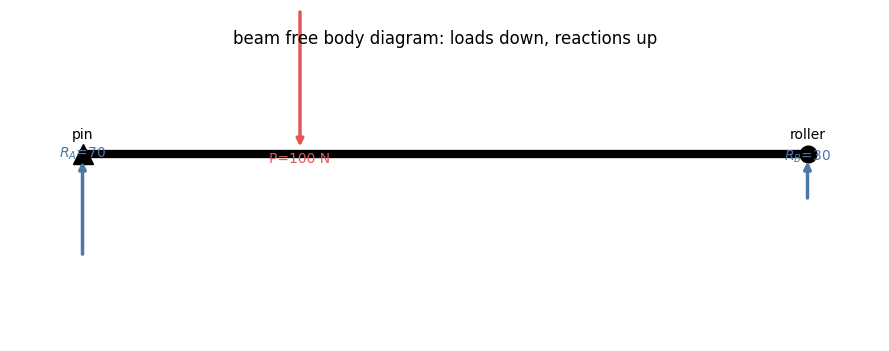

R_A=70 N, R_B=30 N, sum=100 N (= load); R_B = P*x/L = 30


In [2]:
L, P, xl = 10.0, 100.0, 3.0
Ra, Rb = fbd.beam_reactions(L, [(P, xl)])
sc = 0.03   # arrow scale (N -> plot units)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot([0, L], [0, 0], "k", lw=6)                       # the beam
arrow(ax, xl, P*sc+0.1, 0, -P*sc, "#E45756", f"P={P:.0f} N")     # load down
arrow(ax, 0, -Ra*sc-0.1, 0, Ra*sc, "#4C78A8", f"$R_A$={Ra:.0f}")  # reaction up at A
arrow(ax, L, -Rb*sc-0.1, 0, Rb*sc, "#4C78A8", f"$R_B$={Rb:.0f}")  # reaction up at B
ax.plot(0, 0, "k^", ms=14); ax.plot(L, 0, "ko", ms=12)   # pin (triangle), roller (circle)
ax.text(0, 0.35, "pin", ha="center"); ax.text(L, 0.35, "roller", ha="center")
ax.set(xlim=(-1, L+1), ylim=(-4, 2.2), title="beam free body diagram: loads down, reactions up")
ax.axis("off"); plt.tight_layout(); plt.show()
print(f"R_A={Ra:.0f} N, R_B={Rb:.0f} N, sum={Ra+Rb:.0f} N (= load); R_B = P*x/L = {P*xl/L:.0f}")

## 2. Slide the load along the beam

Moment balance makes the reactions vary **linearly** with load position: put the load over a
support and that support takes it all; over the middle, they split evenly. This is the lever rule
you feel carrying a plank with a friend.

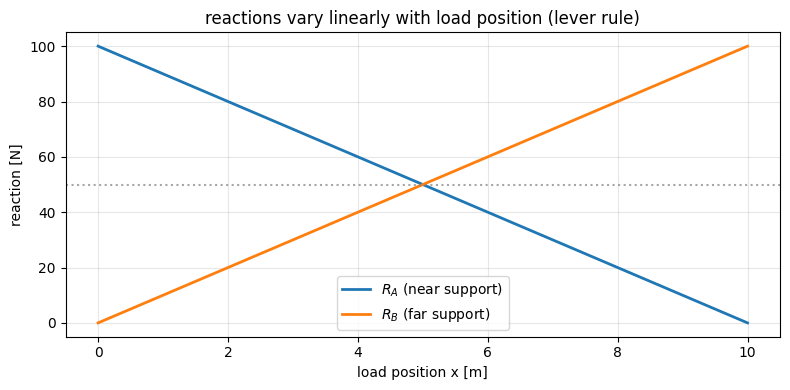

In [3]:
xs = np.linspace(0, L, 100)
Ras, Rbs = zip(*[fbd.beam_reactions(L, [(P, xp)]) for xp in xs])
plt.figure(figsize=(8, 4))
plt.plot(xs, Ras, lw=2, label="$R_A$ (near support)")
plt.plot(xs, Rbs, lw=2, label="$R_B$ (far support)")
plt.axhline(P/2, color="gray", ls=":", alpha=0.7)
plt.xlabel("load position x [m]"); plt.ylabel("reaction [N]")
plt.title("reactions vary linearly with load position (lever rule)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Ladder against a smooth wall

Now a ladder: its **weight** acts at the center, the **floor** pushes up (normal) and sideways
(friction), and the **smooth wall** pushes horizontally (normal only, no friction). Moment balance
about the base gives the wall force, and the friction it demands sets the minimum grip needed.

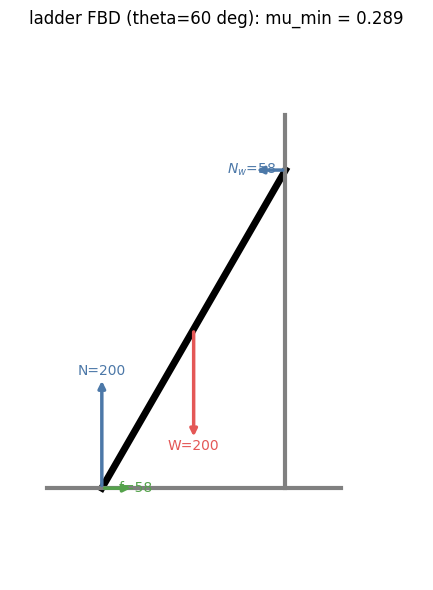

N=200 (=W), f=57.7, N_w=57.7; mu_min=f/N=0.2887 = 1/(2 tan60)=0.2887
assembled reactions in equilibrium? True


In [4]:
W, th, Lad = 200.0, np.radians(60), 4.0
loads = [((0.0, -W), (0.5*Lad*np.cos(th), 0.5*Lad*np.sin(th)))]
rx = [((0.0, 1.0), (0.0, 0.0)), ((1.0, 0.0), (0.0, 0.0)),
      ((-1.0, 0.0), (Lad*np.cos(th), Lad*np.sin(th)))]
m, rf = fbd.solve_reactions(loads, rx)
N, f, Nw = m
tx, ty = Lad*np.cos(th), Lad*np.sin(th)
s = 0.006
fig, ax = plt.subplots(figsize=(5.5, 6))
ax.plot([0, tx], [0, ty], "k", lw=5)                     # the ladder
ax.plot([tx, tx], [0, ty+0.6], "0.5", lw=3)              # the wall
ax.plot([-0.6, tx+0.6], [0, 0], "0.5", lw=3)             # the floor
arrow(ax, 0.5*tx, 0.5*ty, 0, -W*s, "#E45756", f"W={W:.0f}")       # weight down
arrow(ax, 0, 0, 0, N*s, "#4C78A8", f"N={N:.0f}")                   # floor normal
arrow(ax, 0, 0, f*s, 0, "#54A24B", f"f={f:.0f}")                   # floor friction
arrow(ax, tx, ty, -Nw*s, 0, "#4C78A8", f"$N_w$={Nw:.0f}")          # wall normal
ax.set(xlim=(-1, tx+1.5), ylim=(-1, ty+1.5), aspect="equal",
       title=f"ladder FBD (theta=60 deg): mu_min = {f/N:.3f}")
ax.axis("off"); plt.tight_layout(); plt.show()
print(f"N={N:.0f} (=W), f={f:.1f}, N_w={Nw:.1f}; mu_min=f/N={f/N:.4f} = 1/(2 tan60)={1/(2*np.tan(th)):.4f}")
print("assembled reactions in equilibrium?", fbd.is_in_equilibrium(loads + rf))

## 4. Steeper is safer: $\mu_{min}=\dfrac{1}{2\tan\theta}$

Solve the ladder at every angle and the required friction is $1/(2\tan\theta)$ -- a shallow ladder
needs enormous grip (it wants to slide out), a steep one almost none. That is why you stand a
ladder up steeply, and why a ladder on ice (low $\mu$) must be near-vertical to be safe.

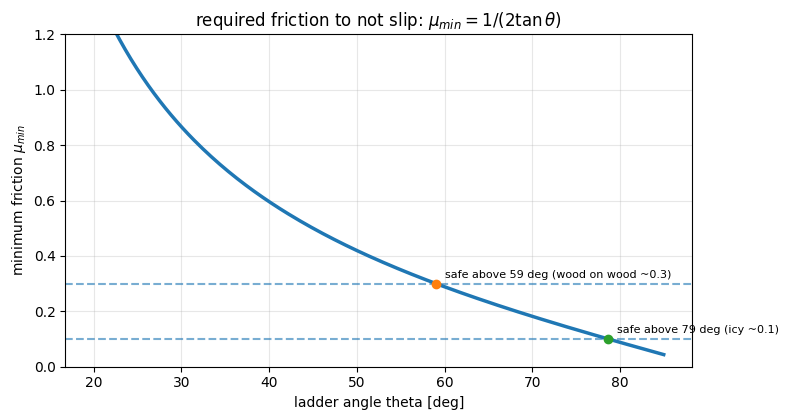

In [5]:
thetas = np.radians(np.linspace(20, 85, 200))
mu = 1 / (2 * np.tan(thetas))
plt.figure(figsize=(8, 4.3))
plt.plot(np.degrees(thetas), mu, lw=2.5)
for muref, name in [(0.3, "wood on wood ~0.3"), (0.1, "icy ~0.1")]:
    plt.axhline(muref, ls="--", alpha=0.6)
    ang = np.degrees(np.arctan(1/(2*muref)))
    plt.plot(ang, muref, "o"); plt.text(ang+1, muref+0.02, f"safe above {ang:.0f} deg ({name})", fontsize=8)
plt.xlabel("ladder angle theta [deg]"); plt.ylabel("minimum friction $\\mu_{min}$")
plt.title("required friction to not slip: $\\mu_{min}=1/(2\\tan\\theta)$"); plt.ylim(0, 1.2)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## What we did

* A free body diagram is every force on one body; equilibrium is $\sum F_x=\sum F_y=\sum M=0$,
  three equations that solve for the support reactions.
* The **beam** reactions come from moment balance (lever rule) and vary linearly with load
  position; the **ladder** needs friction $\mu_{min}=1/(2\tan\theta)$, so steep is safe.
* Same $A\mathbf x=\mathbf b$ solve as `dgs/statics_linalg.py` (a whole truss) -- here for one
  rigid body. Any force works, including the Lorentz force on a charge.